In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

In [25]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [27]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", 0).astype(float)

In [28]:
df = df.drop("customerID", axis=1)

In [29]:
X = df.drop("Churn", axis=1)
y = df["Churn"].map({"Yes": 1, "No": 0})

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

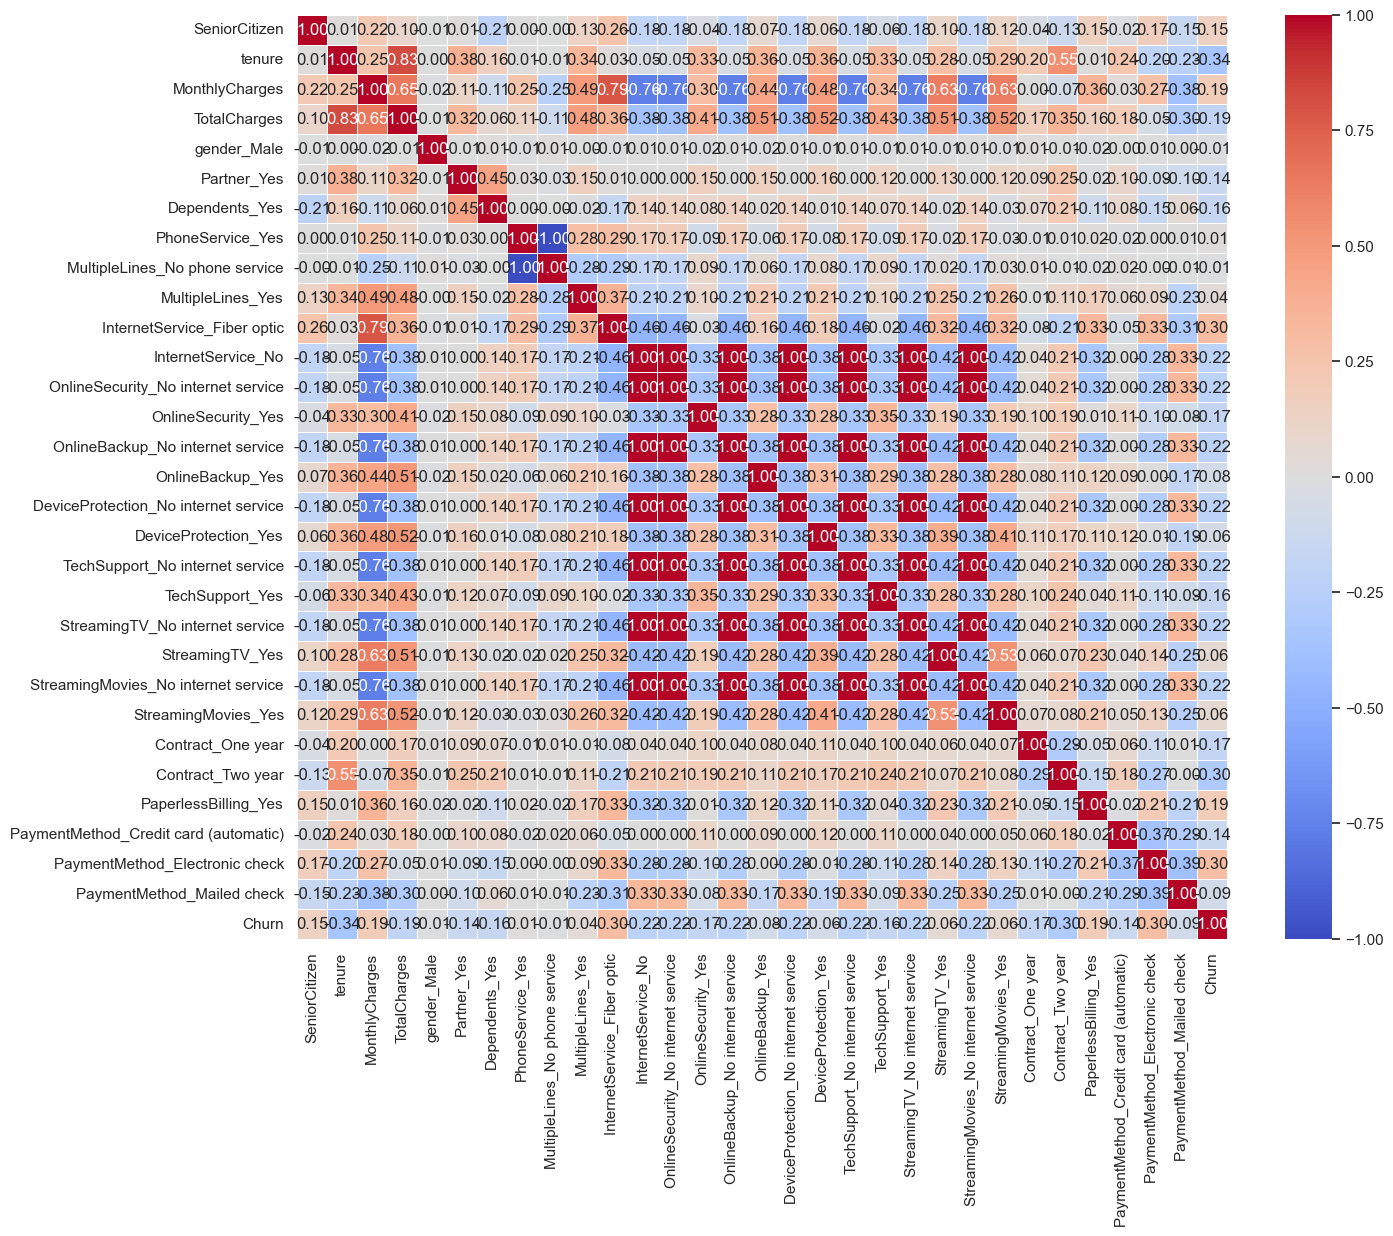

In [31]:
X_train_temp = pd.get_dummies(X_train, drop_first=True)
X_train_temp["Churn"] = y_train

plt.figure(figsize=(15, 12))
sns.heatmap(X_train_temp.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidth=0.5)
plt.show()

In [32]:
X_train = X_train.drop("TotalCharges", axis=1)
X_test = X_test.drop("TotalCharges", axis=1)

In [33]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 2142 to 860
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5634 non-null   object 
 1   SeniorCitizen     5634 non-null   int64  
 2   Partner           5634 non-null   object 
 3   Dependents        5634 non-null   object 
 4   tenure            5634 non-null   int64  
 5   PhoneService      5634 non-null   object 
 6   MultipleLines     5634 non-null   object 
 7   InternetService   5634 non-null   object 
 8   OnlineSecurity    5634 non-null   object 
 9   OnlineBackup      5634 non-null   object 
 10  DeviceProtection  5634 non-null   object 
 11  TechSupport       5634 non-null   object 
 12  StreamingTV       5634 non-null   object 
 13  StreamingMovies   5634 non-null   object 
 14  Contract          5634 non-null   object 
 15  PaperlessBilling  5634 non-null   object 
 16  PaymentMethod     5634 non-null   object 
 17

In [34]:
numeric_features = ["MonthlyCharges", "SeniorCitizen", "tenure"]
categorical_features = [col for col in X_train.columns if col not in numeric_features]

In [35]:
categorical_features

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [36]:
traditional_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features)
    ]
)

In [37]:
traditional_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVC": SVC(random_state=42),
    "KNN": KNeighborsClassifier()
}

tree_models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
    "XGBoost": XGBClassifier(enable_categorical=True, random_state=42)
}

In [38]:
print("--- TRADITIONAL MODELS ---")
for name, model in traditional_models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", traditional_preprocessor),
        ("classifier", model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    print(f"\nModel: {name}")
    print(classification_report(y_test, y_pred))

print("-"*50)
print("\n--- TREE MODELS ---")
for name, model in tree_models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", tree_preprocessor),
        ("classifier", model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    print(f"\nModel: {name}")
    print(classification_report(y_test, y_pred))

--- TRADITIONAL MODELS ---

Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.69      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409


Model: SVC
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1036
           1       0.69      0.52      0.60       373

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Model: KNN
              precision    recall  f1-score   support

           0       0.84      0.85      0.84      1036
           1       0.57      0.54      0.55       373

    accuracy                           0.77      1409
   macro avg       0.70      0.70      0.70      

In [39]:
scale_pos_weight_value = sum(y_train == 0) / sum(y_train == 1)

In [40]:
traditional_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
    "SVC": SVC(random_state=42, class_weight="balanced"),
    "KNN": KNeighborsClassifier()
}

tree_models = {
    "Random Forest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    "LightGBM": LGBMClassifier(random_state=42, class_weight="balanced"),
    "XGBoost": XGBClassifier(enable_categorical=True, random_state=42, scale_pos_weight=scale_pos_weight_value)
}

In [41]:
print("--- TRADITIONAL MODELS ---")
for name, model in traditional_models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", traditional_preprocessor),
        ("classifier", model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    print(f"\nModel: {name}")
    print(classification_report(y_test, y_pred))

print("-"*50)
print("\n--- TREE MODELS ---")
for name, model in tree_models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", tree_preprocessor),
        ("classifier", model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    print(f"\nModel: {name}")
    print(classification_report(y_test, y_pred))

--- TRADITIONAL MODELS ---

Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.73      0.81      1036
           1       0.52      0.82      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.81      0.75      0.77      1409


Model: SVC
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1036
           1       0.53      0.80      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409


Model: KNN
              precision    recall  f1-score   support

           0       0.84      0.85      0.84      1036
           1       0.57      0.54      0.55       373

    accuracy                           0.77      1409
   macro avg       0.70      0.70      0.70      

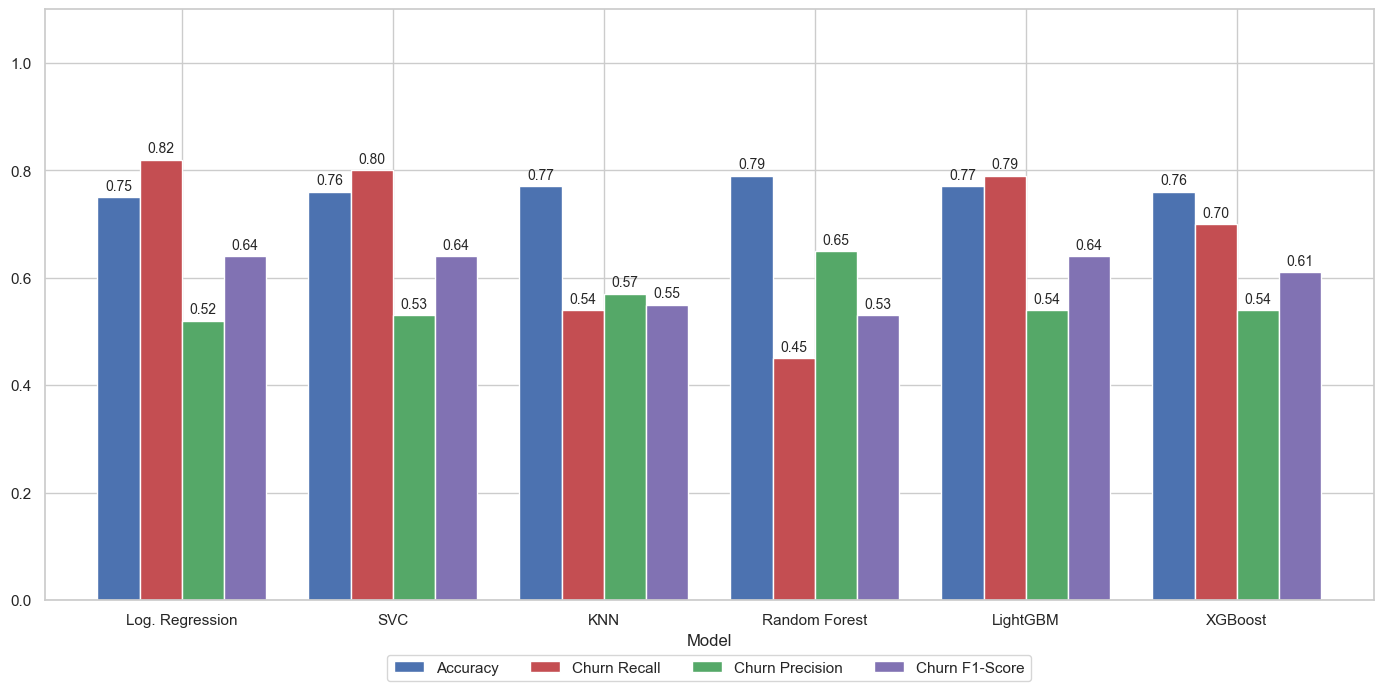

In [42]:
sns.set_theme(style="whitegrid")

data = {
    'Model': ['Log. Regression', 'SVC', 'KNN', 'Random Forest', 'LightGBM', 'XGBoost'],
    'Accuracy': [0.75, 0.76, 0.77, 0.79, 0.77, 0.76],
    'Churn Recall': [0.82, 0.80, 0.54, 0.45, 0.79, 0.70],
    'Churn Precision': [0.52, 0.53, 0.57, 0.65, 0.54, 0.54],
    'Churn F1-Score': [0.64, 0.64, 0.55, 0.53, 0.64, 0.61]
}

df_metrics = pd.DataFrame(data)

ax = df_metrics.set_index("Model").plot(
    kind='bar',
    figsize=(14, 7),
    color=['#4c72b0', '#c44e52', '#55a868', '#8172b3'],
    width=0.8
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.15), ncol=4, fontsize=11) 
ax.set_ylim([0, 1.1])

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                xytext=(0, 3), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

In [43]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ]
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42, max_iter=2000))
])

param_grid = {
    "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["saga", "liblinear"],
    "classifier__class_weight": ["balanced", None]
}

In [44]:
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=5, scoring="f1", n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)
y_pred = grid_search.predict(X_test)
print("Report:\n")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Params: {'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}
Report:

              precision    recall  f1-score   support

           0       0.92      0.73      0.81      1036
           1       0.52      0.82      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.81      0.76      0.77      1409



In [45]:
preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features)
    ]
)

pipeline_lgbm = Pipeline(steps=[
    ("preprocessor", preprocessor_lgbm),
    ("classifier", LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1))
])

lgbm_param_grid = {
    'classifier__n_estimators': [50, 100, 200],      
    'classifier__learning_rate': [0.01, 0.05, 0.1],    
    'classifier__num_leaves': [15, 31, 63],           
    'classifier__max_depth': [-1, 3, 5, 10],           
    'classifier__min_child_samples': [10, 20, 30],    
    'classifier__colsample_bytree': [0.8, 1.0]
}

In [46]:
grid_search_lgbm = GridSearchCV(estimator=pipeline_lgbm, param_grid=lgbm_param_grid, cv=5, n_jobs=-1, verbose=1, scoring="f1")
grid_search_lgbm.fit(X_train, y_train)

print("Best Params:", grid_search_lgbm.best_params_)
y_pred = grid_search_lgbm.predict(X_test)
print("Report:\n")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Best Params: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 10, 'classifier__min_child_samples': 30, 'classifier__n_estimators': 100, 'classifier__num_leaves': 63}
Report:

              precision    recall  f1-score   support

           0       0.92      0.73      0.82      1036
           1       0.53      0.82      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409

